## 生成比赛要求的图案


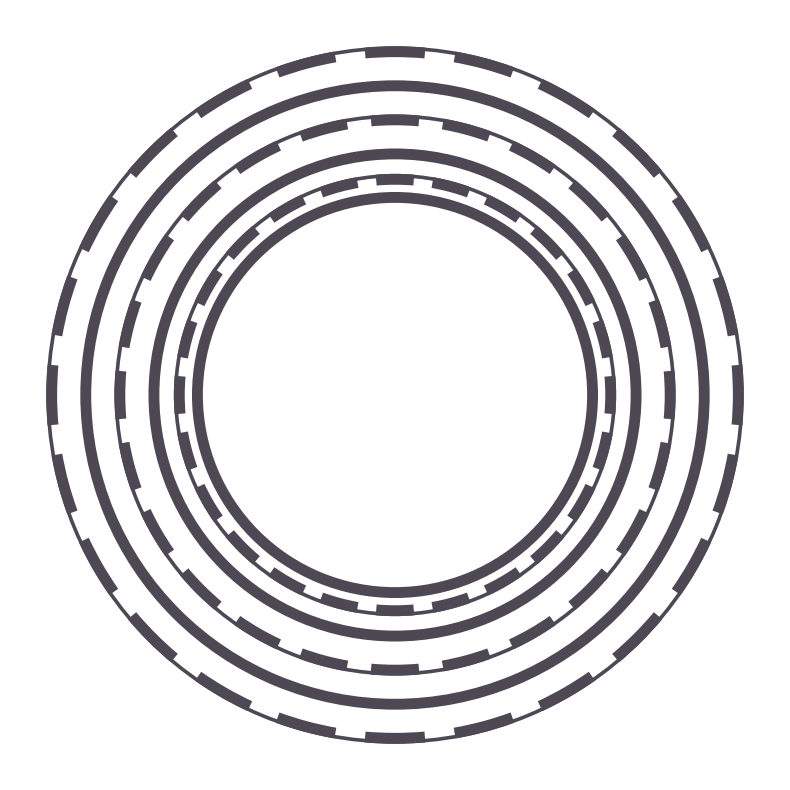

In [ ]:
# 基础复刻
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def preview_proportional_encoder(phi=50.0):
    """
    预览根据图纸比例重构疏密关系的 6 圈编码器盘
    :param phi: 基准内直径 (mm)
    """
    # 1. 基础几何参数设定 (单位: mm)
    w_track = 1.5                 # 统一的轨道宽度 (设为1.5mm以留出密集的内圈间隙)
    g_outer = 3.2                 # 3轨到6轨之间较稀疏的固定间隙 
    
    # 2. 计算 6 个轨道的精确内外半径
    track_radii = []
    
    # --- 内圈密集区域 (基于图纸标注的 2.5 和 3.5 步距) ---
    # 1号圈 (Solid)
    r_in_1 = (phi + 3.0) / 2.0
    r_out_1 = r_in_1 + w_track
    track_radii.append((r_in_1, r_out_1))
    
    # 2号圈 (Serrated) - 内边到1号内边距离为 2.5 mm
    r_in_2 = r_in_1 + 2.5
    r_out_2 = r_in_2 + w_track
    track_radii.append((r_in_2, r_out_2))
    
    # 3号圈 (Solid) - 内边到2号内边距离为 3.5 mm
    r_in_3 = r_in_2 + 3.5
    r_out_3 = r_in_3 + w_track
    track_radii.append((r_in_3, r_out_3))
    
    # --- 外圈稀疏区域 (3轨到6轨间距相同且较大) ---
    # 4号圈 (Serrated)
    r_in_4 = r_out_3 + g_outer
    r_out_4 = r_in_4 + w_track
    track_radii.append((r_in_4, r_out_4))
    
    # 5号圈 (Solid)
    r_in_5 = r_out_4 + g_outer
    r_out_5 = r_in_5 + w_track
    track_radii.append((r_in_5, r_out_5))
    
    # 6号圈 (Serrated)
    r_in_6 = r_out_5 + g_outer
    r_out_6 = r_in_6 + w_track
    track_radii.append((r_in_6, r_out_6))
    
    # 3. 轨道类型配置
    tracks_config = [
        {'type': 'solid'},     # 1号圈
        {'type': 'serrated'},  # 2号圈
        {'type': 'solid'},     # 3号圈
        {'type': 'serrated'},  # 4号圈
        {'type': 'solid'},     # 5号圈
        {'type': 'serrated'}   # 6号圈
    ]
    
    # 锯齿参数
    n_teeth = 24
    period_deg = 360.0 / n_teeth
    tooth_deg = period_deg * (2.0 / 3.0)  # 齿宽占 2/3
    w_line = w_track / 3.0                # 外连接细线宽度
    
    dark_color = '#4E4854'  # 经典紫灰色
    
    # 计算画布的显示范围 (最外圈往外留 5mm 边距)
    max_r = r_out_6 + 5.0
    
    # 4. 创建绘图窗口
    fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
    ax.set_aspect('equal')
    ax.axis('off')  # 隐藏坐标轴
    
    ax.set_xlim(-max_r, max_r)
    ax.set_ylim(-max_r, max_r)
    
    # 5. 开始渲染每一圈
    for idx, (r_in, r_out) in enumerate(track_radii):
        config = tracks_config[idx]
        
        if config['type'] == 'solid':
            # 绘制实心圆环
            ring = patches.Wedge(
                center=(0, 0), 
                r=r_out, 
                theta1=0, 
                theta2=360, 
                width=w_track, 
                facecolor=dark_color, 
                edgecolor='none'
            )
            ax.add_patch(ring)
            
        elif config['type'] == 'serrated':
            # a. 绘制外圈的连续细连接线 (从 r_out 向内扩展 w_line)
            outer_rim = patches.Wedge(
                center=(0, 0),
                r=r_out,
                theta1=0,
                theta2=360,
                width=w_line,
                facecolor=dark_color,
                edgecolor='none'
            )
            ax.add_patch(outer_rim)
            
            # b. 绘制 24 个向内延伸的实心齿 (宽度为完整的 w_track)
            for k in range(n_teeth):
                center_angle = 90.0 + k * period_deg
                theta1 = center_angle - tooth_deg / 2
                theta2 = center_angle + tooth_deg / 2
                
                tooth = patches.Wedge(
                    center=(0, 0), 
                    r=r_out, 
                    theta1=theta1, 
                    theta2=theta2, 
                    width=w_track, 
                    facecolor=dark_color, 
                    edgecolor='none'
                )
                ax.add_patch(tooth)
                
    # 6. 展示交互式预览窗口
    plt.tight_layout()
    plt.show()

# 运行预览
preview_proportional_encoder(phi=50.0)

In [ ]:
## 批量生成，以下标来命名中心点，例如：(300, 493).jpg

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgb

# =========================
# 配置参数
# =========================
EXPORT_BATCH = True              # 是否批量导出
PREVIEW_N = 20                     # 预览数量，当前先 n=1
SAVE_DIR = os.path.join(os.getcwd(), "circle")

CANVAS_SIZE = 320
DPI = 100
BG_BASE = 245
BG_CLIP_MIN = 190
BG_CLIP_MAX = 255

PHI = 50.0
W_TRACK = 1.5
G_OUTER = 3.2

SCALE_MIN = 0.6
SCALE_MAX = 2
CENTER_MARGIN = 5

BASE_COLOR = "#4E4854"
COLOR_JITTER = 0.2              # 颜色扰动幅度，0~1 之间建议小一些

N_TEETH = 24
TOOTH_RATIO = 2.0 / 3.0
W_LINE_RATIO = 1.0 / 3.0

# 噪点参数
NOISE_BASE = 3.2
NOISE_REGION_COUNT = 12
NOISE_SIGMA_MIN = 12
NOISE_SIGMA_MAX = 55
NOISE_REGION_STRENGTH_MIN = 2.0
NOISE_REGION_STRENGTH_MAX = 8.5

SPOT_DENSITY = 0.02
SPOT_VALUES = [-28, -18, -10, 6, 12]
SPOT_PROBS = [0.18, 0.28, 0.28, 0.16, 0.10]

# 条状阴影参数
BAND_COUNT_MIN = 1
BAND_COUNT_MAX = 4.5
BAND_ALPHA_MIN = 0.08
BAND_ALPHA_MAX = 0.23
BAND_WIDTH_MIN = 18
BAND_WIDTH_MAX = 55
BAND_BLUR_SIGMA_MIN = 8
BAND_BLUR_SIGMA_MAX = 21


# =========================
# 预计算环参数
# =========================
track_radii = []

r_in_1 = (PHI + 3.0) / 2.0
r_out_1 = r_in_1 + W_TRACK
track_radii.append((r_in_1, r_out_1))

r_in_2 = r_in_1 + 2.5
r_out_2 = r_in_2 + W_TRACK
track_radii.append((r_in_2, r_out_2))

r_in_3 = r_in_2 + 3.5
r_out_3 = r_in_3 + W_TRACK
track_radii.append((r_in_3, r_out_3))

r_in_4 = r_out_3 + G_OUTER
r_out_4 = r_in_4 + W_TRACK
track_radii.append((r_in_4, r_out_4))

r_in_5 = r_out_4 + G_OUTER
r_out_5 = r_in_5 + W_TRACK
track_radii.append((r_in_5, r_out_5))

r_in_6 = r_out_5 + G_OUTER
r_out_6 = r_in_6 + W_TRACK
track_radii.append((r_in_6, r_out_6))

tracks_config = [
    {"type": "solid"},
    {"type": "serrated"},
    {"type": "solid"},
    {"type": "serrated"},
    {"type": "solid"},
    {"type": "serrated"}
]

period_deg = 360.0 / N_TEETH
tooth_deg = period_deg * TOOTH_RATIO
w_line = W_TRACK * W_LINE_RATIO


# =========================
# 第一步：绘制同心圆图案
# =========================
def render_encoder_pattern(canvas_size):
    scale = np.random.uniform(SCALE_MIN, SCALE_MAX)
    max_r = r_out_6 * scale

    cx = np.random.randint(
        int(np.ceil(max_r + CENTER_MARGIN)),
        int(np.floor(canvas_size - max_r - CENTER_MARGIN)) + 1
    )
    cy = np.random.randint(
        int(np.ceil(max_r + CENTER_MARGIN)),
        int(np.floor(canvas_size - max_r - CENTER_MARGIN)) + 1
    )

    base_rgb = np.array(to_rgb(BASE_COLOR))
    color_jitter = np.random.uniform(-COLOR_JITTER, COLOR_JITTER, 3)
    draw_color = np.clip(base_rgb + color_jitter, 0, 1)

    fig = plt.figure(figsize=(canvas_size / DPI, canvas_size / DPI), dpi=DPI, facecolor="white")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, canvas_size)
    ax.set_ylim(canvas_size, 0)
    ax.set_aspect("equal")
    ax.axis("off")

    # 先铺一层纯背景，后面再叠加噪点与阴影
    ax.imshow(
        np.full((canvas_size, canvas_size), BG_BASE),
        cmap="gray",
        vmin=0,
        vmax=255,
        origin="upper",
        extent=[0, canvas_size, canvas_size, 0]
    )

    for idx, (r_in, r_out) in enumerate(track_radii):
        r_out_s = r_out * scale

        if tracks_config[idx]["type"] == "solid":
            ring = patches.Wedge(
                center=(cx, cy),
                r=r_out_s,
                theta1=0,
                theta2=360,
                width=W_TRACK * scale,
                facecolor=draw_color,
                edgecolor="none"
            )
            ax.add_patch(ring)

        else:
            outer_rim = patches.Wedge(
                center=(cx, cy),
                r=r_out_s,
                theta1=0,
                theta2=360,
                width=w_line * scale,
                facecolor=draw_color,
                edgecolor="none"
            )
            ax.add_patch(outer_rim)

            for k in range(N_TEETH):
                center_angle = 90.0 + k * period_deg
                theta1 = center_angle - tooth_deg / 2
                theta2 = center_angle + tooth_deg / 2

                tooth = patches.Wedge(
                    center=(cx, cy),
                    r=r_out_s,
                    theta1=theta1,
                    theta2=theta2,
                    width=W_TRACK * scale,
                    facecolor=draw_color,
                    edgecolor="none"
                )
                ax.add_patch(tooth)

    return fig, ax, cx, cy, scale


# =========================
# 第二步：增加噪点
# =========================
def add_noise_background(ax, canvas_size):
    y, x = np.mgrid[0:canvas_size, 0:canvas_size]

    noise_strength = np.full((canvas_size, canvas_size), NOISE_BASE)

    for _ in range(NOISE_REGION_COUNT):
        noise_x = np.random.uniform(0, canvas_size)
        noise_y = np.random.uniform(0, canvas_size)
        sigma = np.random.uniform(NOISE_SIGMA_MIN, NOISE_SIGMA_MAX)
        strength = np.random.uniform(NOISE_REGION_STRENGTH_MIN, NOISE_REGION_STRENGTH_MAX)

        noise_strength += strength * np.exp(
            -((x - noise_x) ** 2 + (y - noise_y) ** 2) / (2 * sigma ** 2)
        )

    background = BG_BASE + np.random.normal(0, 1, (canvas_size, canvas_size)) * noise_strength

    density = noise_strength / noise_strength.max()
    spot_mask = np.random.random((canvas_size, canvas_size)) < density * SPOT_DENSITY
    spot_noise = np.random.choice(SPOT_VALUES, size=(canvas_size, canvas_size), p=SPOT_PROBS)
    background[spot_mask] += spot_noise[spot_mask]

    background = np.clip(background, BG_CLIP_MIN, BG_CLIP_MAX)

    ax.images[0].set_data(background)


# =========================
# 第三步：增加条状带阴影
# =========================
def add_band_shadows(ax, canvas_size):
    y, x = np.mgrid[0:canvas_size, 0:canvas_size]
    band_shadow = np.zeros((canvas_size, canvas_size), dtype=float)

    band_count = np.random.randint(BAND_COUNT_MIN, BAND_COUNT_MAX + 1)

    for _ in range(band_count):
        theta = np.random.uniform(0, np.pi)
        width = np.random.uniform(BAND_WIDTH_MIN, BAND_WIDTH_MAX)
        alpha = np.random.uniform(BAND_ALPHA_MIN, BAND_ALPHA_MAX)
        blur_sigma = np.random.uniform(BAND_BLUR_SIGMA_MIN, BAND_BLUR_SIGMA_MAX)

        x0 = np.random.uniform(0, canvas_size)
        y0 = np.random.uniform(0, canvas_size)

        dist = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
        band = np.exp(-(dist ** 2) / (2 * width ** 2))
        soft = np.exp(-(dist ** 2) / (2 * blur_sigma ** 2))

        band_shadow += alpha * np.maximum(band, soft)

    band_shadow = np.clip(band_shadow, 0, 0.25)

    ax.imshow(
        np.zeros((canvas_size, canvas_size)),
        cmap="gray",
        vmin=0,
        vmax=255,
        alpha=band_shadow,
        origin="upper",
        extent=[0, canvas_size, canvas_size, 0]
    )


# =========================
# 主函数：预览 / 导出
# =========================
def main():
    os.makedirs(SAVE_DIR, exist_ok=True)

    for i in range(PREVIEW_N):
        fig, ax, cx, cy, scale = render_encoder_pattern(CANVAS_SIZE)
        add_noise_background(ax, CANVAS_SIZE)
        add_band_shadows(ax, CANVAS_SIZE)

        filename = f"({cx}, {cy}).jpg"
        save_path = os.path.join(SAVE_DIR, filename)

        print(f"[{i+1}/{PREVIEW_N}] scale={scale:.4f}, center=({cx}, {cy}), filename={filename}")

        if EXPORT_BATCH:
            fig.savefig(save_path, dpi=DPI, facecolor="white")
            print("saved to:", save_path)

        # plt.show()


if __name__ == "__main__":
    main()